
<div dir=ltr align=center>

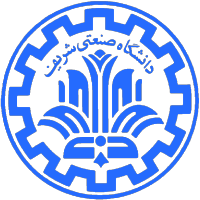

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Clustering: Gaussian Mixture Model <br>
<font color=696880 size=4>
    Prepared by Benyamin Ghanbari <br>

<font color=696880 size=2>
    Curated by Alireza Mirshafieian

____

# Student Information

In [ ]:
full_name = 'Mahdi Ghorbani'

# Customer Segmentation Using GMM

## Description:
In this project, you will implement a Gaussian Mixture Model (GMM) from scratch and use it to perform customer segmentation based on demographic and behavioral data. Customer segmentation is the process of grouping customers into clusters such that customers within the same cluster are more similar to each other than to those in other clusters. In this assignment, segmentation is done using a probabilistic clustering approach, where each customer is assigned a probability of belonging to each cluster based on features such as Age, Annual Income, and Spending Score.

**⚠️ Notice:** You are allowed to use only the imported libraries and must follow the provided function structure.

# 📝 **Project Instructions**

1. **Load the customer dataset**  
   Load the dataset containing customer information such as **Age, Annual Income, Spending Score**, and optionally **Gender**.

2. **Feature selection**  
    Anything that you need.

3. **Standardize features**  
   Normalize the numerical features using **standardization** so that each feature has **mean 0 and standard deviation 1**.

4. **Initialize GMM parameters**  
   Randomly initialize **cluster weights, means, and covariance matrices** for a chosen number of clusters **K**.

5. **Expectation-Maximization (EM) steps**  
   - **Expectation step:** Compute the **responsibility** of each cluster for every customer.  
   - **Maximization step:** Update **weights, means, and covariances** based on responsibilities.  
   - Repeat until **log-likelihood converges** or **max iterations** is reached.

6. **Multiple initializations**  
   Run the GMM algorithm **multiple times** with different random seeds and select the model with the **highest log-likelihood** to avoid poor local minima.

7. **Select the optimal number of clusters**  
   Compute **BIC (Bayesian Information Criterion)** for different values of **K** and choose the one with the **lowest BIC**.

8. **Assign clusters to customers**  
   For the final model, assign each customer to the cluster with the **highest responsibility**.

9. **Visualize clusters**  
   - **2D scatter plots:** Plot feature pairs (e.g., Age vs Income, Age vs Spending Score) with points colored by cluster.  
   - **Cluster centroids and circles:** Highlight **cluster centers** and **spread** using semi-transparent colored circles.  
   - **3D scatter plot:** Visualize clusters in 3D with **centroids marked**.



# 📤 **Expected Output**

- A **clustered customer dataset** showing each customer assigned to a **GMM cluster**  
- **2D scatter plots** of feature pairs (e.g., Age vs Income, Age vs Spending Score, Income vs Spending Score) with:  
  - Cluster points colored by cluster  
  - **Centroids** marked  
  - **Semi-transparent circles** showing cluster spread  
- A **3D scatter plot** visualizing all three features with cluster centroids highlighted  
- A **BIC vs. K plot** showing the Bayesian Information Criterion for different numbers of clusters, helping identify the **optimal K**  
- **Observe** which features distinguish clusters and how changing **K** affects segmentation quality


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Circle

In [2]:
# read data

df = pd.read_csv('Mall_Customers.csv')
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [3]:
# data prepration (feature selection and scaling)

# Select numerical features for clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

def standard_scale(X):

    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0)
    X_scaled = (X - means) / stds

    return X_scaled, means, stds

X_scaled, means_X, stds_X = standard_scale(X)


In [4]:
# GMM from scratch

def gaussian_pdf_all(X, mean, cov):

    n_features = X.shape[1]
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)

    norm_const = -0.5 * n_features * np.log(2 * np.pi) - 0.5 * np.log(det_cov)

    diff = X - mean
    exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)

    return np.exp(norm_const + exponent)

def initialize_parameters(X, k, rng):

    n_samples, n_features = X.shape

    # Initialize weights uniformly
    weights = np.ones(k) / k

    # Initialize means randomly from data points
    indices = rng.choice(n_samples, k, replace=False)
    means = X[indices].copy()

    # Initialize covariance matrices as identity
    covs = np.array([np.eye(n_features) for _ in range(k)])

    return weights, means, covs

def expectation_step(X, weights, means, covs):

    n_samples = X.shape[0]
    k = len(weights)

    # Compute probability for each cluster
    prob = np.zeros((n_samples, k))
    for i in range(k):
        prob[:, i] = gaussian_pdf_all(X, means[i], covs[i])

    # Weight probabilities
    weighted_prob = prob * weights

    # Normalize to get responsibilities
    sum_weighted = np.sum(weighted_prob, axis=1, keepdims=True)
    sum_weighted[sum_weighted == 0] = 1e-10  # Avoid division by zero
    resp = weighted_prob / sum_weighted

    return resp

def maximization_step(X, resp):

    n_samples, n_features = X.shape
    k = resp.shape[1]

    # Compute N_k (effective number of points in each cluster)
    N_k = np.sum(resp, axis=0)

    # Update weights
    weights = N_k / n_samples

    # Update means
    means = np.zeros((k, n_features))
    for i in range(k):
        means[i] = np.sum(resp[:, i:i+1] * X, axis=0) / N_k[i]

    # Update covariance matrices
    covs = np.zeros((k, n_features, n_features))
    for i in range(k):
        diff = X - means[i]
        weighted_diff = resp[:, i:i+1] * diff
        covs[i] = (weighted_diff.T @ diff) / N_k[i]

        # Add small value to diagonal for numerical stability
        covs[i] += np.eye(n_features) * 1e-6

    return weights, means, covs

def compute_log_likelihood(X, weights, means, covs):

    k = len(weights)
    n_samples = X.shape[0]

    # Compute probability for each cluster
    prob = np.zeros((n_samples, k))
    for i in range(k):
        prob[:, i] = weights[i] * gaussian_pdf_all(X, means[i], covs[i])

    # Sum probabilities and compute log
    ll = np.sum(np.log(np.sum(prob, axis=1)))

    return ll

def gmm_train(X, k, max_iter=200, tol=1e-4, seed=None):

    # Set random seed
    if seed is not None:
        rng = np.random.RandomState(seed)
    else:
        rng = np.random.RandomState()

    # Initialize parameters
    weights, means, covs = initialize_parameters(X, k, rng)

    # Initialize log-likelihood
    ll_old = -np.inf

    # EM iterations
    for iteration in range(max_iter):
        # E-step
        resp = expectation_step(X, weights, means, covs)

        # M-step
        weights, means, covs = maximization_step(X, resp)

        # Compute log-likelihood
        ll_new = compute_log_likelihood(X, weights, means, covs)

        # Check convergence
        if np.abs(ll_new - ll_old) < tol:
            print(f"Converged after {iteration + 1} iterations")
            break

        ll_old = ll_new

    # Final log-likelihood
    ll = compute_log_likelihood(X, weights, means, covs)

    return weights, means, covs, resp, ll

In [5]:
# compute best k using BIC

def compute_bic(ll, k, n, d):

    # Number of parameters:
    # weights: (k-1) independent parameters (sum to 1)
    # means: k * d parameters
    # covariance: k * d * (d+1) / 2 parameters
    num_params = (k-1) + (k * d) + (k * d * (d+1) // 2)

    return -2*ll + num_params * np.log(n)

bic_values = []
k_range = range(2,9)
best_models = []

# to do
# Train GMM for different k values and compute BIC
for k in k_range:
    # Train GMM with multiple initializations
    n_init = 5
    best_ll = -np.inf
    best_model = None

    for init in range(n_init):
        weights, means, covs, resp, ll = gmm_train(X_scaled, k, seed=42+init)

        if ll > best_ll:
            best_ll = ll
            best_model = (weights, means, covs, resp)

    # Compute BIC
    n_samples, n_features = X_scaled.shape
    bic = compute_bic(best_ll, k, n_samples, n_features)

    bic_values.append(bic)
    best_models.append(best_model)

    print(f"k = {k}: BIC = {bic:.2f}, Log-likelihood = {best_ll:.2f}")

# Find best k (lowest BIC)
best_idx = np.argmin(bic_values)
best_k = k_range[best_idx]
print("\nBest k =", best_k)


Converged after 20 iterations
Converged after 29 iterations
Converged after 32 iterations
Converged after 34 iterations
Converged after 40 iterations
k = 2: BIC = 1656.16, Log-likelihood = -777.75
Converged after 29 iterations
Converged after 38 iterations
Converged after 33 iterations
Converged after 52 iterations
Converged after 23 iterations
k = 3: BIC = 1581.87, Log-likelihood = -714.11
Converged after 40 iterations
Converged after 46 iterations
Converged after 35 iterations
Converged after 95 iterations
Converged after 32 iterations
k = 4: BIC = 1576.18, Log-likelihood = -684.77
Converged after 35 iterations
Converged after 84 iterations
Converged after 36 iterations
Converged after 62 iterations
Converged after 68 iterations
k = 5: BIC = 1576.45, Log-likelihood = -658.42
Converged after 48 iterations
Converged after 64 iterations
Converged after 30 iterations
Converged after 99 iterations
Converged after 38 iterations
k = 6: BIC = 1604.13, Log-likelihood = -645.76
Converged after

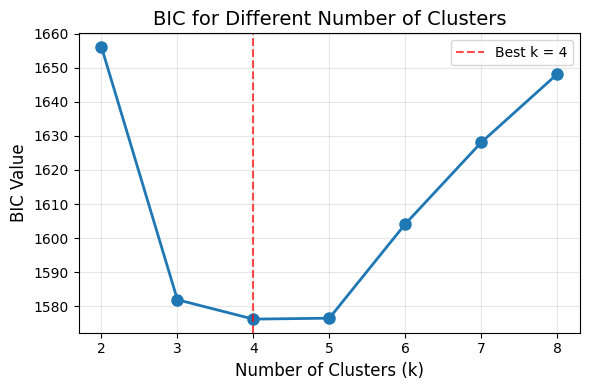

In [7]:
# BIC plot

plt.figure(figsize=(6, 4))
plt.plot(k_range, bic_values, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('BIC Value', fontsize=12)
plt.title('BIC for Different Number of Clusters', fontsize=14)
plt.axvline(x=best_k, color='r', linestyle='--', alpha=0.7, label=f'Best k = {best_k}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(k_range)
plt.tight_layout()
plt.show()


In [8]:
# train final model
weights_final, means_final, covs_final, resp_final, ll_final = gmm_train(X_scaled, best_k, seed=42)
cluster_labels_final = np.argmax(resp_final, axis=1)
df['Cluster'] = cluster_labels_final

Converged after 40 iterations


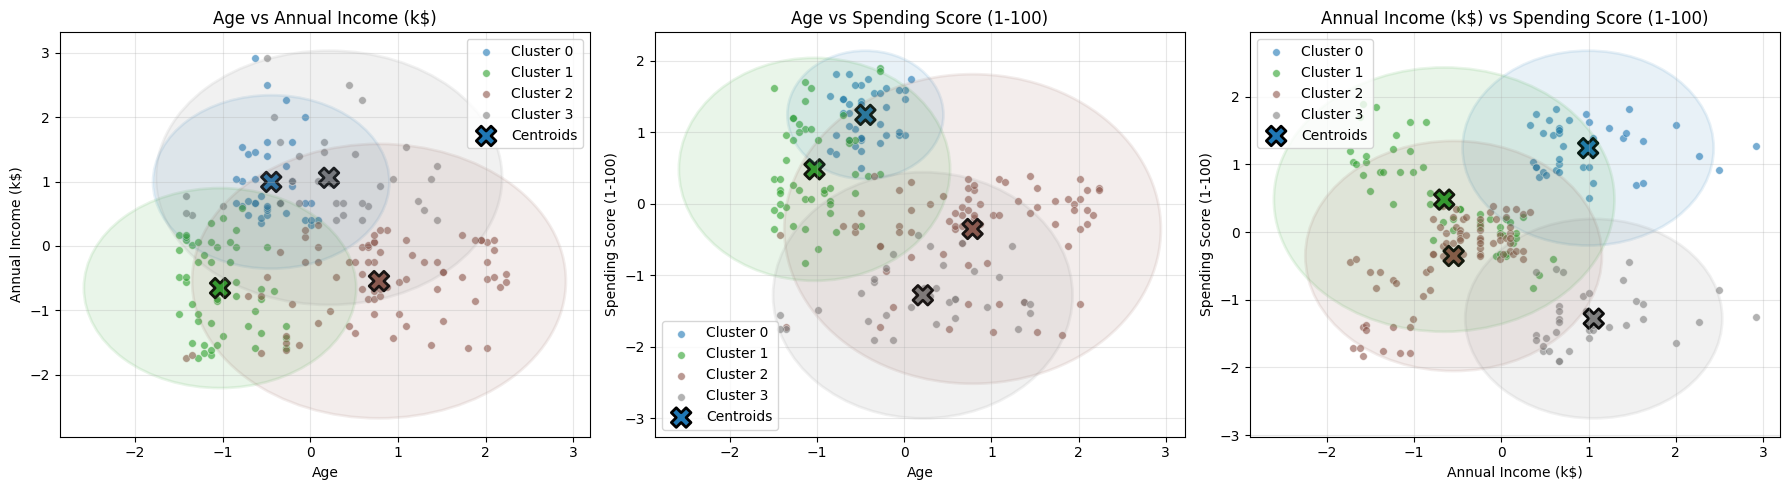

In [10]:
# 2D plot with cluster circles and centroid

def plot_clusters_2d(X, labels, means, covs, feature_names):
    n_clusters = len(np.unique(labels))
    colors = plt.cm.tab10(np.arange(n_clusters) / n_clusters)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    feature_pairs = [(0, 1), (0, 2), (1, 2)]

    for idx, (i, j) in enumerate(feature_pairs):
        ax = axes[idx]

        # Plot data points
        for k in range(n_clusters):
            mask = labels == k
            ax.scatter(X[mask, i], X[mask, j],
                      c=[colors[k]], label=f'Cluster {k}',
                      alpha=0.6, s=30, edgecolors='w', linewidth=0.5)

        # Plot centroids
        ax.scatter(means[:, i], means[:, j],
                  c=colors, marker='X', s=200,
                  edgecolors='black', linewidth=2, label='Centroids')

        # Plot circles representing cluster spread
        for k in range(n_clusters):
            # Calculate circle radius based on standard deviation
            std_i = np.sqrt(covs[k][i, i])
            std_j = np.sqrt(covs[k][j, j])
            radius = np.sqrt(std_i**2 + std_j**2) * 2  # 2 standard deviations

            circle = Circle(xy=means[k, [i, j]], radius=radius,
                           edgecolor=colors[k], facecolor=colors[k],
                           alpha=0.1, linewidth=2)
            ax.add_patch(circle)

        ax.set_xlabel(feature_names[i])
        ax.set_ylabel(feature_names[j])
        ax.set_title(f'{feature_names[i]} vs {feature_names[j]}')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

feature_names = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
plot_clusters_2d(X_scaled, cluster_labels_final, means_final, covs_final, feature_names)

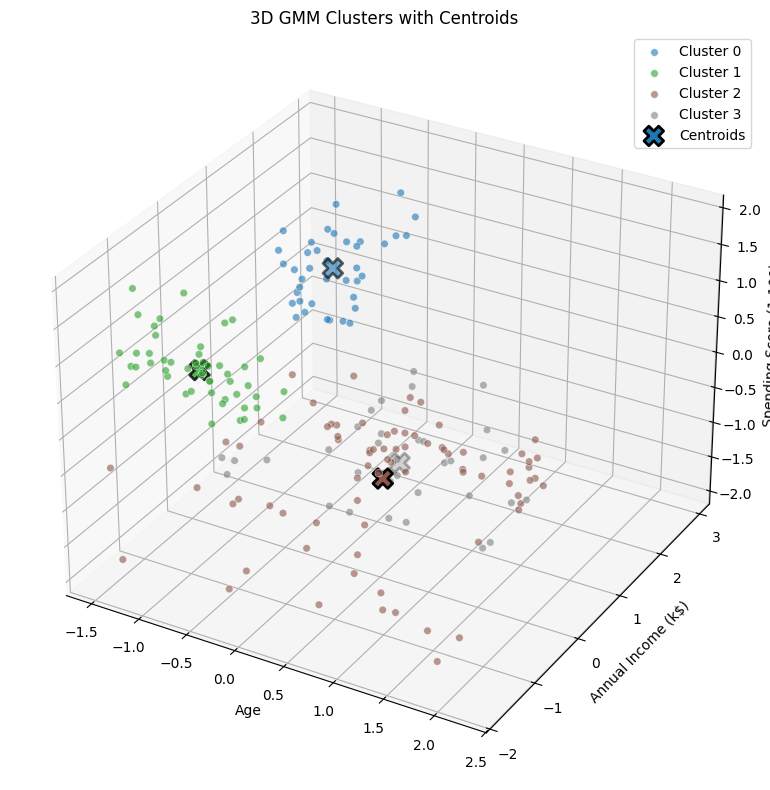

In [11]:
# 3D plot with cluster centroids

def plot_clusters_3d(X, labels, means, feature_names):
    n_clusters = len(np.unique(labels))
    colors = plt.cm.tab10(np.arange(n_clusters) / n_clusters)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot data points
    for k in range(n_clusters):
        mask = labels == k
        ax.scatter(X[mask, 0], X[mask, 1], X[mask, 2],
                  c=[colors[k]], label=f'Cluster {k}',
                  alpha=0.6, s=30, edgecolors='w', linewidth=0.5)

    # Plot centroids
    ax.scatter(means[:, 0], means[:, 1], means[:, 2],
              c=colors, marker='X', s=200,
              edgecolors='black', linewidth=2, label='Centroids')

    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_zlabel(feature_names[2])
    ax.set_title('3D GMM Clusters with Centroids')
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_clusters_3d(X_scaled, cluster_labels_final, means_final, feature_names)


In [12]:
# save segmented result
df['Cluster'] = cluster_labels_final
df.to_csv('customer_segments_gmm.csv', index=False)


In [ ]:
# Your first 10 row shoud be like :



,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,1,Male,19,15,39,3
1,1,2,Male,21,15,81,0
2,2,3,Female,20,16,6,3
3,3,4,Female,23,16,77,0
4,4,5,Female,31,17,40,3
5,5,6,Female,22,17,76,0
6,6,7,Female,35,18,6,3
7,7,8,Female,23,18,94,0
8,8,9,Male,64,19,3,3
9,9,10,Female,30,19,72,0
